<a href="https://colab.research.google.com/github/takeonakamura6-design/lp/blob/main/Biblioteca%20em%20Panda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introdução a biblioteca Panda

Iniciando Experimento: Vetorização vs Iteração...

--- RESULTADOS DO EXPERIMENTO ---
             Método  Tempo de Execução (s)  Amostras Processadas  Performance (amostras/s)
   Iterativo (Loop)               1.685208                 50000              2.966993e+04
Vetorizado (Pandas)               0.002108                 50000              2.372344e+07

Speedup alcançado: 799.58x mais rápido.


/tmp/ipykernel_2251/3219852068.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Método', y='Tempo de Execução (s)', data=results_df, palette='viridis')



Gráfico salvo como 'grafico.png'. Pronto para publicação.


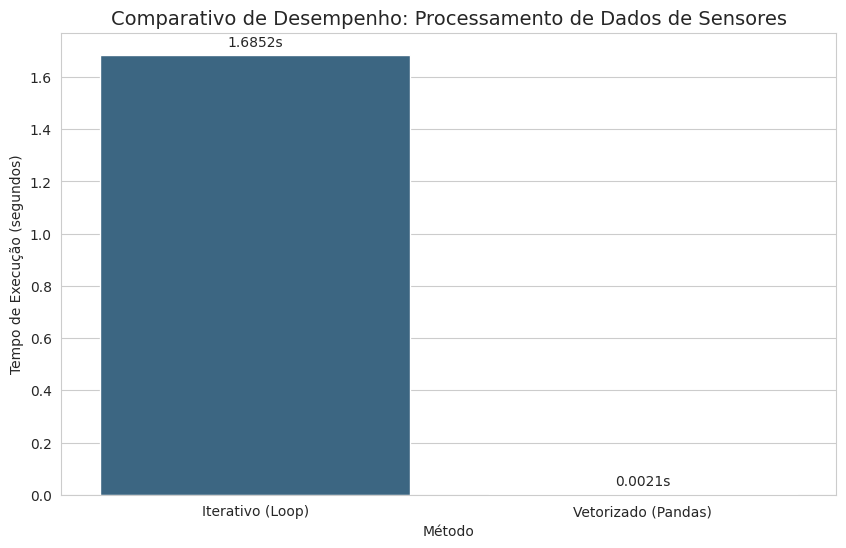

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

def generate_sensor_data(n_samples=1000000):
    """Gera dados sintéticos de sensores para o experimento."""
    np.random.seed(42)
    data = {
        'timestamp': pd.date_range(start='2023-01-01', periods=n_samples, freq='ms'),
        'sensor_read': np.random.uniform(0, 5, n_samples),
        'noise_factor': np.random.normal(0, 0.1, n_samples)
    }
    return pd.DataFrame(data)

def process_iterative(df):
    """Processamento utilizando loop iterativo (Método Ineficiente)."""
    results = []
    for i in range(len(df)):
        # Simula um cálculo de ajuste de sinal
        val = (df['sensor_read'].iloc[i] * 1.5) + df['noise_factor'].iloc[i]
        results.append(val)
    return results

def process_vectorized(df):
    """Processamento utilizando vetorização (Método Eficiente)."""
    # Cálculo direto sobre as colunas (Series)
    return (df['sensor_read'] * 1.5) + df['noise_factor']

def run_experiment():
    # 1. Preparação
    print("Iniciando Experimento: Vetorização vs Iteração...")
    df = generate_sensor_data()

    # Reduzindo amostra para o loop iterativo não travar o Colab (apenas para teste comparativo)
    df_sample = df.head(50000).copy()

    # 2. Teste Iterativo
    start_time = time.time()
    _ = process_iterative(df_sample)
    iterative_time = time.time() - start_time

    # 3. Teste Vetorizado
    start_time = time.time()
    _ = process_vectorized(df_sample)
    vectorized_time = time.time() - start_time

    # 4. Cálculo de Métricas
    speedup = iterative_time / vectorized_time

    results_data = {
        'Método': ['Iterativo (Loop)', 'Vetorizado (Pandas)'],
        'Tempo de Execução (s)': [iterative_time, vectorized_time],
        'Amostras Processadas': [len(df_sample), len(df_sample)],
        'Performance (amostras/s)': [len(df_sample)/iterative_time, len(df_sample)/vectorized_time]
    }

    results_df = pd.DataFrame(results_data)

    # Exibição da Tabela no Terminal
    print("\n--- RESULTADOS DO EXPERIMENTO ---")
    print(results_df.to_string(index=False))
    print(f"\nSpeedup alcançado: {speedup:.2f}x mais rápido.")

    # 5. Geração do Gráfico
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.barplot(x='Método', y='Tempo de Execução (s)', data=results_df, palette='viridis')
    plt.title('Comparativo de Desempenho: Processamento de Dados de Sensores', fontsize=14)
    plt.ylabel('Tempo de Execução (segundos)')

    # Adicionando rótulos de tempo nas barras
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f') + 's',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

    # Salvar para o Zenodo/Artigo
    plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
    print("\nGráfico salvo como 'grafico.png'. Pronto para publicação.")
    plt.show()

if __name__ == "__main__":
    run_experiment()

1. A Fábrica de Dados: O código gera uma tabela (DataFrame) com $10^6$ registros. Isso cria uma carga de trabalho pesada o suficiente para que a diferença de performance seja gritante, simulando um cenário real de Big Data ou IoT.
2. O Método Lento (Iteração): Utiliza um loop for tradicional. O Python precisa "parar" em cada linha, verificar o tipo de dado e aplicar o cálculo. Esse processo é lento porque o interpretador do Python tem um custo operacional alto para cada repetição.
3. O Método Rápido (Vetorização): Em vez de olhar linha por linha, o Pandas envia a coluna inteira para ser processada de uma vez só no nível do hardware (usando instruções C e operações SIMD). É a diferença entre entregar 1.000 cartas uma por uma ou entregar um container inteiro de uma vez.